In [ ]:
!pip install brian2 qiskit pylatexenc qiskit-machine-learning qiskit-aer qiskit-algorithms qiskit_ibm_runtime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 17.4 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
from brian2 import *
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import VQR

def run_adex_vectorized(x, noise=None):
    start_scope()

    defaultclock.dt = 0.01*ms

    x = np.array(x)

    if noise is None:
        noise = np.zeros_like(x)

    noise = np.array(noise)

    assert len(x) == len(noise)

    # ======================
    # Parameter
    # ======================
    C = 281*pF
    gL = 30*nS
    EL = -70.6*mV
    VT = -50.4*mV
    DeltaT = 2*mV
    tauw = 40*ms
    a = 4*nS
    b = 0.08*nA

    Vcut = VT + 5 * DeltaT

    # 🔥 jumlah neuron = panjang x
    N = len(x)

    duration = 1*second
    init_time = 3*second

    bin_size = 10*ms
    num_bins = int(duration / bin_size)

    # ======================
    # Input vector
    # ======================
    I_array = (x + noise) * nA

    # ======================
    # Model
    # ======================
    eqs = """
    dvm/dt=(gL*(EL-vm)+gL*DeltaT*exp((vm-VT)/DeltaT)+I-w)/C : volt
    dw/dt=(a*(vm-EL)-w)/tauw : amp
    I : amp
    Vr:volt
    """

    neuron = NeuronGroup(
        N, model=eqs,
        threshold='vm > Vcut',
        reset="vm = Vr; w += b",
        method='euler'
    )

    neuron.vm = EL
    neuron.w = a * (neuron.vm - EL)
    neuron.Vr = linspace(-48.3 * mV, -47.7 * mV, N)

    # 🔥 assign input per neuron
    neuron.I = I_array

    # ======================
    # Warmup
    # ======================
    run(init_time)

    # ======================
    # Monitor
    # ======================
    spikes = SpikeMonitor(neuron)
    states = StateMonitor(neuron, ['w'], record=True)

    run(duration)

    # ======================
    # OFFSET TIME
    # ======================
    times = (spikes.t - init_time) / second
    time_array = (states.t - init_time) / second

    # ======================
    # FIRING RATE
    # ======================
    firing_rate = spikes.count / duration  # (N,)

    # ======================
    # BINNING SPIKE
    # ======================
    binned_spikes = np.zeros((N, num_bins))

    for idx, t in zip(spikes.i, times):
        if t >= 0:
            b = int(t / (bin_size/second))
            if 0 <= b < num_bins:
                binned_spikes[idx, b] += 1

    # ======================
    # BINNING w
    # ======================
    w_data = states.w / nA

    binned_w = np.zeros((N, num_bins))
    counts = np.zeros((N, num_bins))

    bin_indices = (time_array / (bin_size/second)).astype(int)

    for t_idx, b in enumerate(bin_indices):
        if 0 <= b < num_bins and time_array[t_idx] >= 0:
            binned_w[:, b] += w_data[:, t_idx]
            counts[:, b] += 1

    mask = counts > 0
    binned_w[mask] /= counts[mask]

    # ======================
    # 🔥 AMBIL "LATEST STATE"
    # ======================
    latest_firing_rate = firing_rate              # (N,)
    latest_spike = binned_spikes[:, -1]           # (N,)
    latest_w = binned_w[:, -1]                    # (N,)

    # spike timing terakhir per neuron (optional)
    latest_spike_time = np.full(N, np.nan)

    for i, t in zip(spikes.i, times):
        if t >= 0:
            latest_spike_time[i] = t * 1000  # ms

    # ======================
    # RETURN
    # ======================
    return latest_firing_rate, latest_spike_time, latest_spike, latest_w

# nan values to float
def nan_to_num(array):
    return np.where(np.isnan(array), 0, array)

def quantum_state_preparation(xi):
  len_feature = x[0].shape[-1]
  qc = QuantumCircuit(len_feature*2)

  # add Rx and Rz gates in first len_feature
  for i in range(0, len_feature):
    qc.rx(xi[2][i], i)
    qc.rz(xi[1][i], i)

  # add hadamard in last len_feature
  for i in range(len_feature, len_feature*2):
    qc.h(i)

  qc.barrier()

  # add rzx in last len_feature
  for i in range(0, len_feature):
    for j in range(len_feature, len_feature*2):
      ex_w = xi[3][i]
      qc.cx(j, i)
      qc.rz(ex_w, j)
      qc.cx(i, j)

  qc.barrier()

  return qc

In [ ]:
x = np.linspace(0.5, 1.5, 100)
ex_firig_rate, ex_spike_time, ex_spike, ex_w = run_adex_vectorized(x)

In [ ]:
ex_spike_time = nan_to_num(ex_spike_time)

In [ ]:
print(len(x))
print(f"Firing Rate : {ex_firig_rate}")
print(f"Spike time : {ex_spike_time}")
print(f"Spike : {ex_spike}")
print(f"W : {ex_w}")

100
Firing Rate : [  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   4.
   7.  10.  17.  20.  22.  24.  26.  28.  31.  34.  36.  42.  45.  48.
  52.  55.  60.  63.  67.  71.  75.  78.  81.  85.  88.  90.  93.  96.
  99. 102. 105. 108. 111. 115. 117. 120. 123. 125. 129. 132. 134. 137.
 140. 143. 146. 149. 151. 155. 157. 160. 163. 166. 168. 172. 174. 177.
 179. 183. 185. 188. 190. 194. 197. 199. 202. 205. 207. 210. 212. 216.
 219. 221. 224. 227. 230. 232. 235. 238. 240. 243. 246. 248. 251. 254.
 257. 259.] Hz
Spike time : [  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
   0.     0.     0.   793.08 865.29 975.32 955.43 974.96 970.58 942.66
 991.24 944.48 996.51 993.56 975.   997.5  996.2  967.87 984.05 990.19
 994.89 989.12 999.9  995.47 998.95 995.15 990.03 998.53 996.32 994.2
 993.45 992.89 992.98 993.47 994.35 995.8  997.32 999.08 992.79 994.88
 997.7  992.25 995.25 998.55 993.95 997.63 993.97 997.39 994.45 998.12
 995.49 999.58 996.59 994.74 998.2

In [ ]:
len(ex_firig_rate)

100

In [ ]:
from sklearn.datasets import load_iris

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

iris = load_iris()

In [ ]:
x = iris.data[:, 1:4]
y = iris.data[:, 3]

In [ ]:
x.shape[-1]

3

In [ ]:
x[1]

array([3. , 1.4, 0.2])

In [ ]:
import time

start_time = time.time()
x_adex = []
for i in range(len(x)):
  ex_firing_rate, ex_spike_time, ex_spike, ex_w = run_adex_vectorized(x[i])
  ex_spike_time = nan_to_num(ex_spike_time)
  x_adex.append([ex_firing_rate, ex_spike_time, ex_spike, ex_w])

end_time = time.time()
elapsed_time = end_time - start_time
print(f"elapsed_time : {elapsed_time} s")

elapsed_time : 1138.5316982269287 s


In [ ]:
import json
import numpy as np # Import numpy for array conversion if not already imported

x_adex_json_ready = []
for item in x_adex:
    # item[0] is a Quantity object from brian2 (e.g., array([...]) * unit)
    # item[1], item[2], item[3] are numpy arrays
    x_adex_json_ready.append([
        np.asarray(item[0]).tolist(), # Convert Quantity array to list of floats using np.asarray
        item[1].tolist(),       # Convert numpy array to list
        item[2].tolist(),       # Convert numpy array to list
        item[3].tolist()        # Convert numpy array to list
    ])

data = {
    "x": x_adex_json_ready,
    "y": y.tolist()
}

with open('dataset_adex_iris_dataset.json', 'w') as f:
    json.dump(data, f)

In [ ]:
# download 'dataset_adex_iris_dataset.json'
from google.colab import files
files.download('dataset_adex_iris_dataset.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
x_adex_sample = x_adex[0]

In [ ]:
x_adex_sample[2]

array([6., 2., 0.])

In [ ]:
x_adex_sample[0].shape[-1]

3

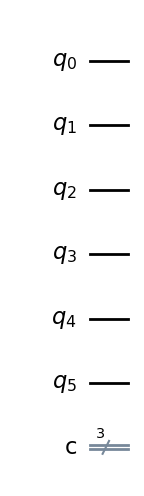

In [ ]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

# qr = QuantumRegister(1, name="quantum")
# cr = ClassicalRegister(1, name="classical")
len_feature = x.shape[-1]
qc = QuantumCircuit(len_feature*2, len_feature)
qc.draw("mpl", filename="quantum_circuit.png")

In [ ]:
# add Rx and Rz gates in first len_feature
for i in range(0, len_feature):
  qc.rx(x_adex_sample[2][i], i)
  qc.rz(x_adex_sample[1][i], i)

# add hadamard in last len_feature
for i in range(len_feature, len_feature*2):
  qc.h(i)

qc.barrier()

# add rzx in last len_feature
for i in range(0, len_feature):
  for j in range(len_feature, len_feature*2):
    ex_w = x_adex_sample[3][i]
    qc.cx(j, i)
    qc.rz(ex_w, j)
    qc.cx(i, j)

qc.barrier()

# add measure qubit to cbit
for i in range(0, len_feature):
  qc.measure(i, i)

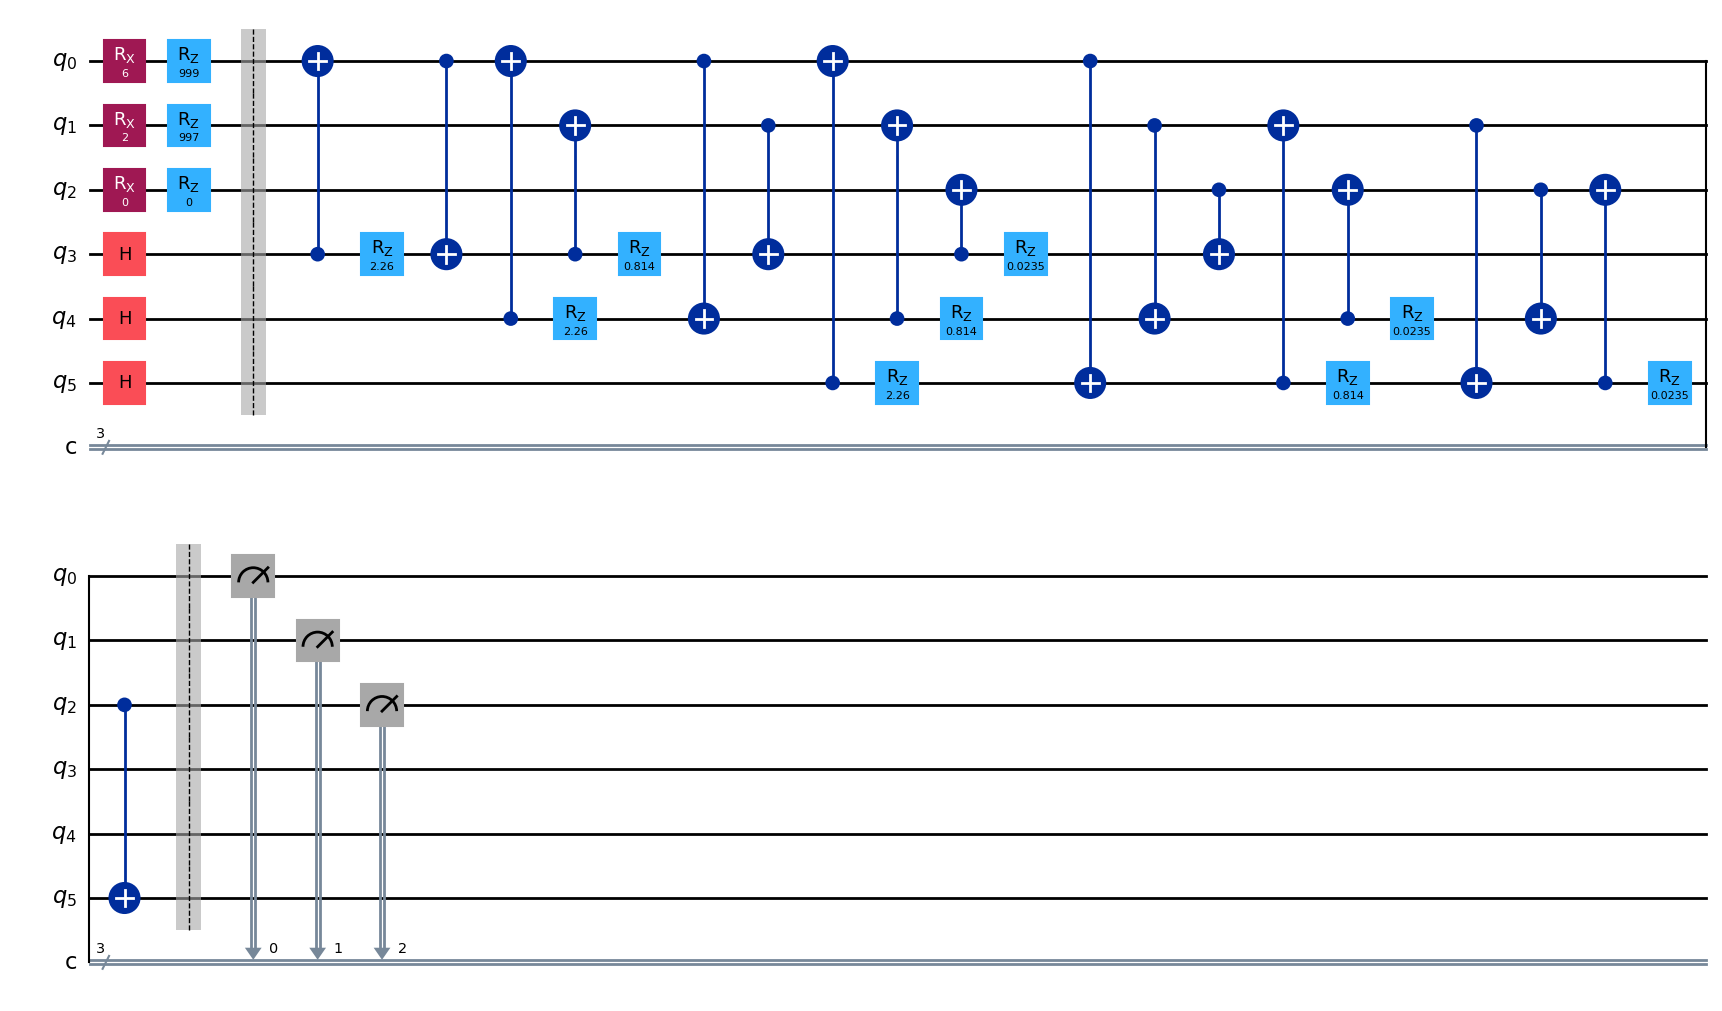

In [ ]:
qc.draw("mpl", filename="quantum_circuit.png")

In [ ]:
x_adex_sample

[array([0.675, 0.224, 0.   ]) * khertz,
 array([998.85, 996.52,   0.  ]),
 array([6., 2., 0.]),
 array([2.26245849, 0.8135174 , 0.02353491])]

In [ ]:
[[0.675, 0.224, 0.   ],
[998.85, 996.52,   0.  ],
[6., 2., 0.],
[2.26245849, 0.8135174 , 0.02353491]]

[[0.675, 0.224, 0.0],
 [998.85, 996.52, 0.0],
 [6.0, 2.0, 0.0],
 [2.26245849, 0.8135174, 0.02353491]]

In [ ]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister

def quantum_state_preparation(xi, w):
  len_feature = x[0].shape[-1]
  len_w = len(w)
  qc = QuantumCircuit(len_feature+len_w)

  # add Rx and Rz gates in first len_feature
  for i in range(0, len_feature):
    qc.rx(xi[2][i], i)
    qc.rz(xi[1][i], i)

  # add hadamard in last len_feature
  for i in range(len_feature, len_feature+len_w):
    qc.h(i)

  qc.barrier()

  # add rzx in last len_feature
  for i in range(len_feature):
    for j in range(len_w):
        target_qubit = len_feature + j

        qc.cx(target_qubit, i)
        qc.rz(float(w[j]), target_qubit)  # <-- FIX: pakai w[j]
        qc.cx(i, target_qubit)

  qc.barrier()

  return qc

In [ ]:
ex_qc = quantum_state_preparation(x_adex_sample, x_adex_sample[3])

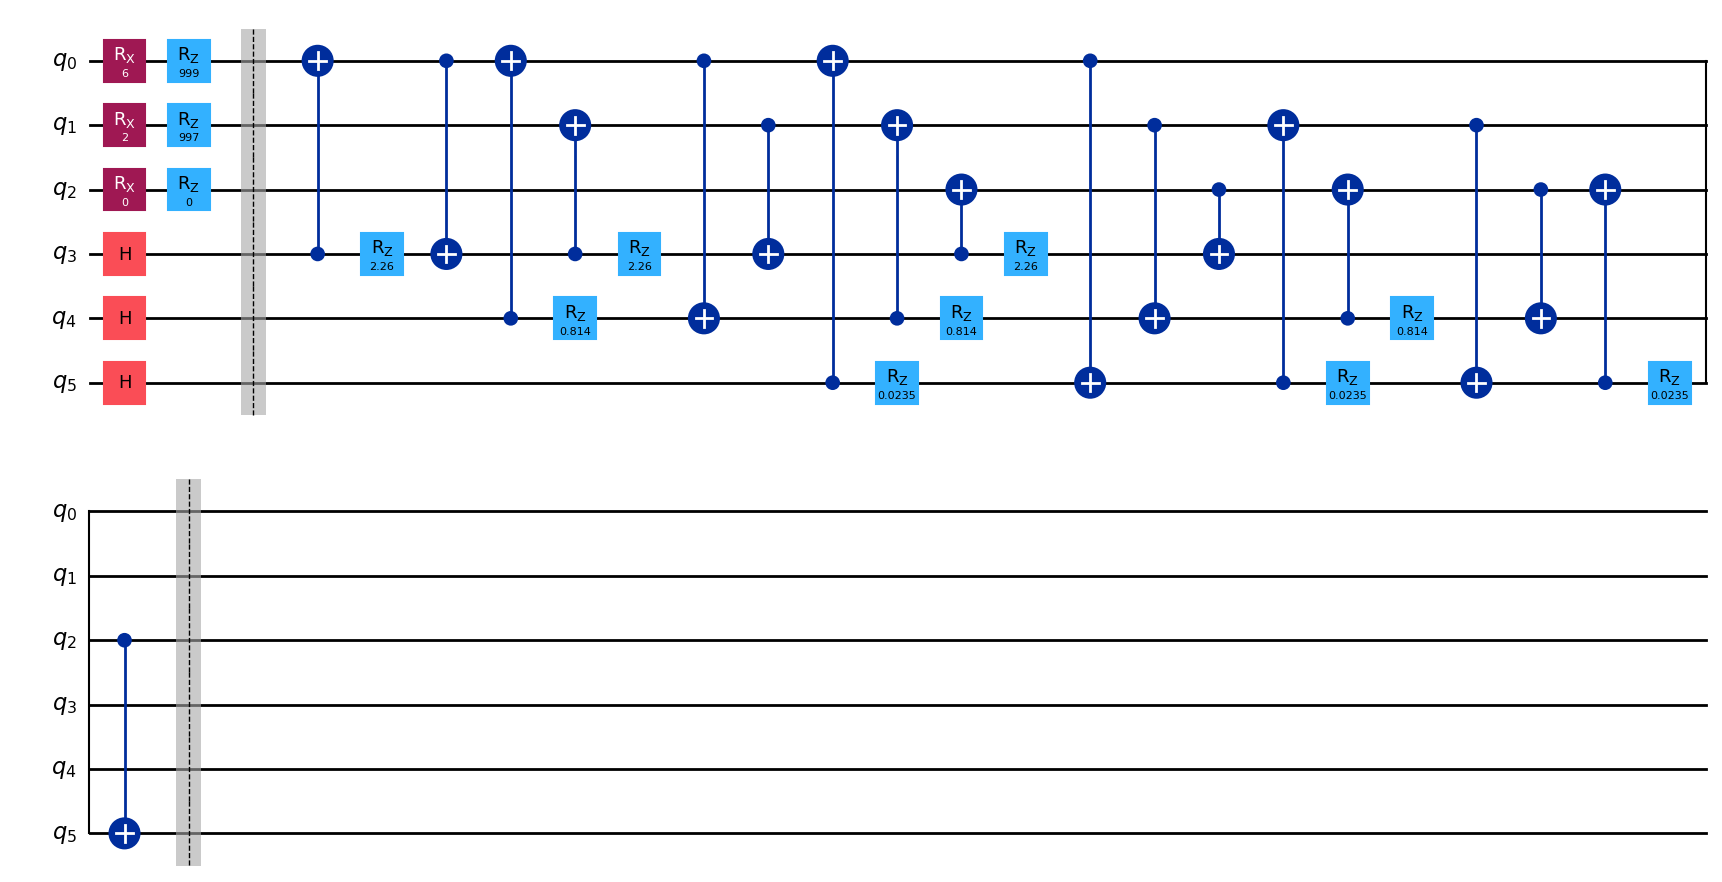

In [ ]:
ex_qc.draw("mpl", filename="quantum_circuit.png")

In [ ]:
from qiskit.circuit import QuantumCircuit, ParameterVector


def iris_adex_style_feature_map(n_features: int):
    """Feature map selaras sirkuit AdEx di atas: 2 * n_features qubit —
    Rx/Rz pada n qubit pertama, H pada n qubit kedua, lalu blok CX–Rz–CX
    (sudut Rz memakai x[i] per indeks fitur, seperti ex_w = xi[3][i])."""
    x_params = ParameterVector("x", n_features)
    qc = QuantumCircuit(2 * n_features)
    for i in range(n_features):
        qc.rx(x_params[i], i)
        qc.rz(x_params[i], i)
    for j in range(n_features, 2 * n_features):
        qc.h(j)
    qc.barrier()
    for i in range(n_features):
        for j in range(n_features, 2 * n_features):
            qc.cx(j, i)
            qc.rz(x_params[i], j)
            qc.cx(i, j)
    qc.barrier()
    return qc

In [ ]:
import numpy as np
from qiskit.circuit.library import RealAmplitudes
from qiskit_machine_learning.algorithms.regressors import VQR
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from qiskit.primitives import StatevectorEstimator


WARNING    /usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
 [py.warnings]
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(



In [ ]:
optimizer = COBYLA(maxiter=30)

In [ ]:
# Regresi Iris: x = iris.data[:, 1:4] (3 fitur), y = iris.data[:, 3]
n_features = int(x.shape[1])
feature_map = iris_adex_style_feature_map(n_features)
num_qubits = 2 * n_features
ansatz = RealAmplitudes(num_qubits, entanglement="linear", reps=1)
estimator = StatevectorEstimator()
vqr = VQR(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    estimator=estimator,
)
# Skala fitur & target agar sudut rotasi stabil untuk encoder
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x_train = scaler_x.fit_transform(np.asarray(x, dtype=float))
y_train = scaler_y.fit_transform(np.asarray(y, dtype=float).reshape(-1, 1)).ravel()

NameError: name 'ParameterVector' is not defined

In [ ]:
#@title Train Model with tqdm Progress Bar
import time

start_time = time.time()
print("Training VQR (Iris regression)...")
vqr.fit(x_train, y_train)

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

In [ ]:
# y_pred_scaled = vqr.predict(x_train)
# y_pred = scaler_y.inverse_transform(np.asarray(y_pred_scaled).reshape(-1, 1)).ravel()